# TM Barrier Scenario 1 — Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TARGET = 'total_barrier_kcal_mol'

## 1. Load & inspect data

In [ ]:
df = pd.read_csv(r"TM_barriers_with_standard_state_corrections.csv")

# Short labels for boron species
boh2_map = {
    'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid': 'BOH2-cpd2',
    'BOH2Ar_compound_6_benzofuran-2-boronic_acid':                    'BOH2-cpd6',
    'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid':        'BOH2-cpd9',
}
bpin_map = {
    'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate': 'BPin-cpd2',
    'BPinAr_compound_6_benzofuran-2-boronate':                   'BPin-cpd6',
    'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate':        'BPin-cpd9',
}
df['BOH2_short'] = df['boron species (BOH2)'].map(boh2_map)
df['BPin_short'] = df['boron species (BPin)'].map(bpin_map)

print(df.shape)
df.head(10)

(150, 16)


,temp_C,substrate,boron species (BOH2),boron species (BPin),ligand,case,dG_TM_react_8_kcal_mol,dG_TM_react_9_kcal_mol,dG_TM_reactant_10_kcal_mol,dG_TM_reactant_kcal_mol,dG_TM_TS_kcal_mol,dG_TM_product_kcal_mol,total_barrier_kcal_mol,standard_state,BOH2_short,BPin_short
0,30,3_bromoquinoline,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PCy3,case1,-38.740725,-34.456225,-16.080042,-12.939543,-4.703498,-17.924137,34.037227,1M,BOH2-cpd2,BPin-cpd2
1,30,3_chloropyridine,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PCy3,case2,-23.664102,-26.739132,-14.031111,-13.511532,-1.920602,-17.544525,24.818531,1M,BOH2-cpd2,BPin-cpd2
2,30,3_chloropyridine,BOH2Ar_compound_6_benzofuran-2-boronic_acid,BPinAr_compound_6_benzofuran-2-boronate,PCy3,case3,-23.664102,-35.567664,-17.321253,-15.258012,-3.152180,-20.384924,32.415484,1M,BOH2-cpd6,BPin-cpd6
3,30,2_chloropyridine,BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boro...,BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boro...,PCy3,case4,-38.945258,-39.173027,-21.234537,-7.010991,-5.349420,-30.554566,33.823608,1M,BOH2-cpd9,BPin-cpd9
4,30,3_bromoquinoline,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PPh3,case1,-21.575405,-35.076833,-14.429718,-13.414736,-6.568322,-15.654545,28.508511,1M,BOH2-cpd2,BPin-cpd2
5,30,3_chloropyridine,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PPh3,case2,-17.801671,-32.046421,-15.204878,-13.222539,-5.882878,-15.945789,26.163543,1M,BOH2-cpd2,BPin-cpd2
6,30,3_chloropyridine,BOH2Ar_compound_6_benzofuran-2-boronic_acid,BPinAr_compound_6_benzofuran-2-boronate,PPh3,case3,-17.801671,-34.211086,-16.432677,-14.239075,-5.101034,-17.054047,29.110053,1M,BOH2-cpd6,BPin-cpd6
7,30,2_chloropyridine,BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boro...,BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boro...,PPh3,case4,-20.858988,-43.291174,-18.555299,-14.962747,-9.892165,-27.855002,33.399009,1M,BOH2-cpd9,BPin-cpd9
8,30,3_chloropyridine,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,AmPhos,case2,-21.468156,-22.295201,-10.988025,-9.613925,-1.700177,-17.467250,20.595024,1M,BOH2-cpd2,BPin-cpd2
9,30,3_chloropyridine,BOH2Ar_compound_6_benzofuran-2-boronic_acid,BPinAr_compound_6_benzofuran-2-boronate,AmPhos,case3,-21.468156,-26.522132,-14.330074,-9.956246,-1.439697,-17.161524,25.082434,1M,BOH2-cpd6,BPin-cpd6


In [ ]:
df.info()

In [3]:
df[TARGET].describe().round(3)

count    150.000
mean      21.270
std        6.982
min        5.620
25%       15.636
50%       21.219
75%       26.448
max       34.037
Name: total_barrier_kcal_mol, dtype: float64

In [ ]:
print('Temperatures (°C):', sorted(df['temp_C'].unique()))
print('Substrates:       ', df['substrate'].unique().tolist())
print('Ligands:          ', df['ligand'].unique().tolist())
print('BOH2 species:     ', df['BOH2_short'].unique().tolist())
print('BPin species:     ', df['BPin_short'].unique().tolist())
print('Cases:            ', sorted(df['case'].unique()))

## 2. Overall distribution

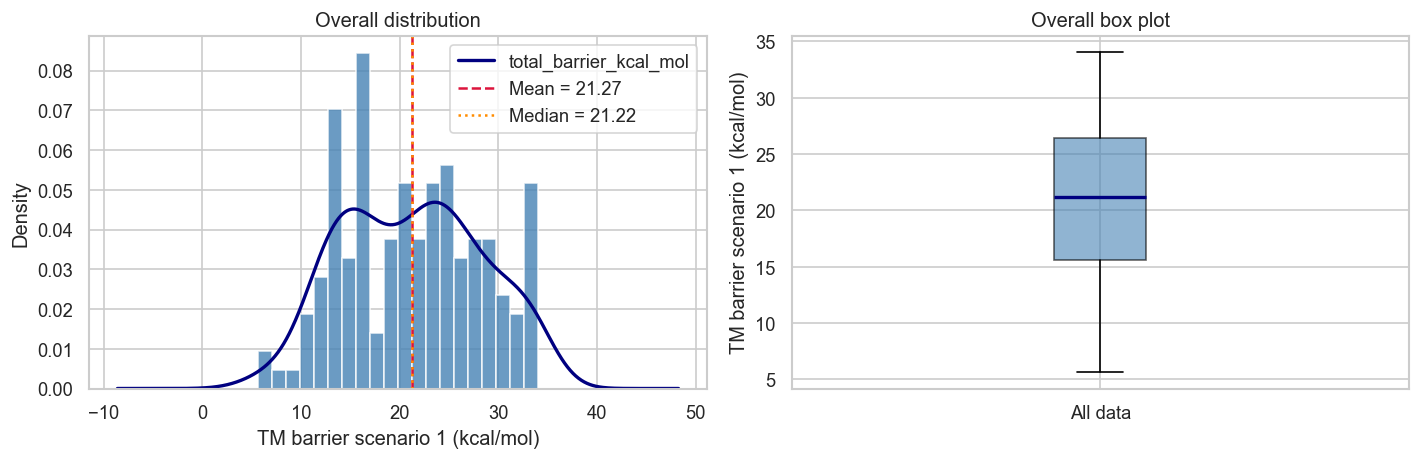

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
axes[0].hist(df[TARGET], bins=20, color='steelblue', edgecolor='white', alpha=0.8, density=True)
df[TARGET].plot.kde(ax=axes[0], color='navy', linewidth=2)
axes[0].axvline(df[TARGET].mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {df[TARGET].mean():.2f}')
axes[0].axvline(df[TARGET].median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {df[TARGET].median():.2f}')
axes[0].set_xlabel('TM barrier scenario 1 (kcal/mol)')
axes[0].set_ylabel('Density')
axes[0].set_title('Overall distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_ylabel('TM barrier scenario 1 (kcal/mol)')
axes[1].set_xticklabels(['All data'])
axes[1].set_title('Overall box plot')

plt.tight_layout()
plt.show()

## 3. Analysis by temperature

In [5]:
temp_stats = (
    df.groupby('temp_C')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
)
temp_stats

,mean,median,std,min,max,count
temp_C,,,,,,
30,23.044,24.758,7.255,10.202,34.037,30
50,22.098,23.674,7.108,9.056,33.852,30
70,21.212,22.399,6.969,7.909,33.665,30
90,20.380,21.143,6.805,6.764,33.475,30
110,19.615,19.843,6.694,5.620,33.283,30


C:\Users\livio\AppData\Local\Temp\ipykernel_25836\1080378927.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_temp, labels=labels, patch_artist=True,


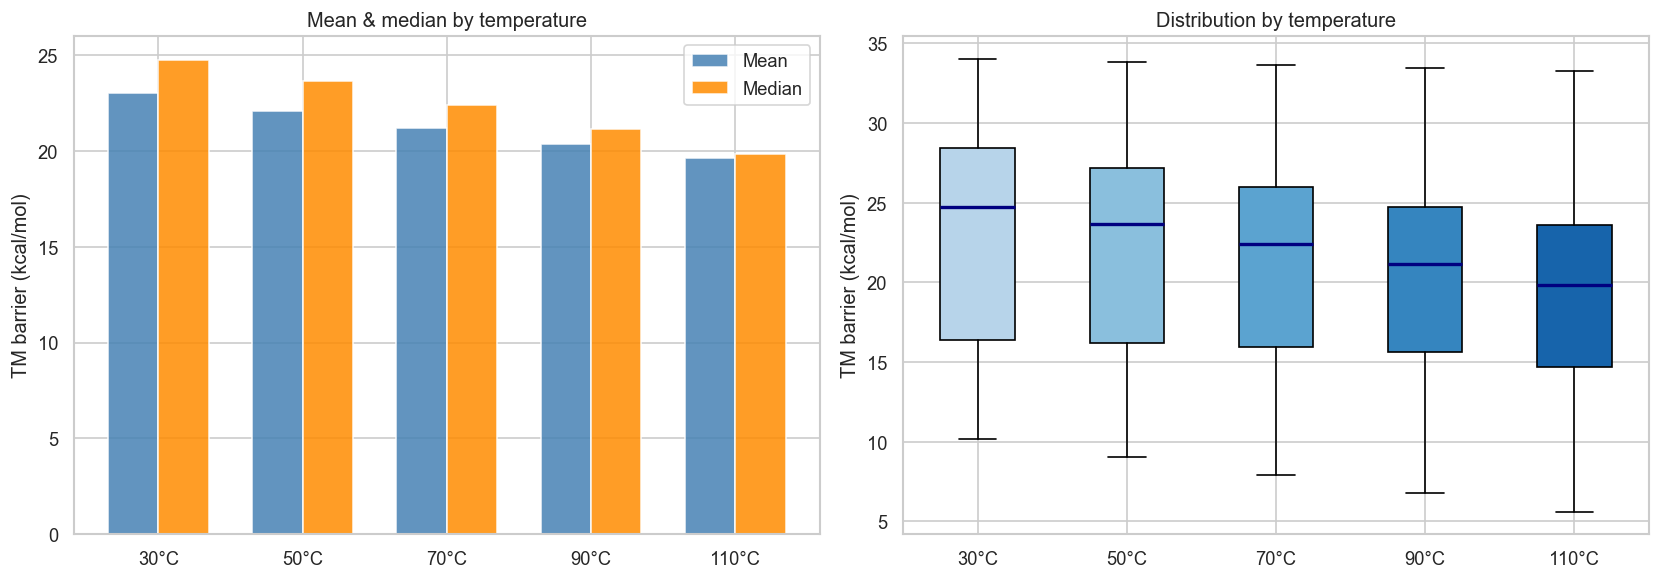

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

temps = sorted(df['temp_C'].unique())
labels = [f'{t}°C' for t in temps]
x = np.arange(len(temps))
w = 0.35

axes[0].bar(x - w/2, temp_stats['mean'],   width=w, label='Mean',   color='steelblue',  alpha=0.85)
axes[0].bar(x + w/2, temp_stats['median'], width=w, label='Median', color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by temperature')
axes[0].legend()

data_by_temp = [df[df['temp_C'] == t][TARGET].values for t in temps]
bp = axes[1].boxplot(data_by_temp, labels=labels, patch_artist=True,
                     medianprops=dict(color='navy', linewidth=2))
colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(temps)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by temperature')

plt.tight_layout()
plt.show()

C:\Users\livio\AppData\Local\Temp\ipykernel_25836\274765645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='temp_C', y=TARGET, palette='Blues', inner='box', ax=ax)


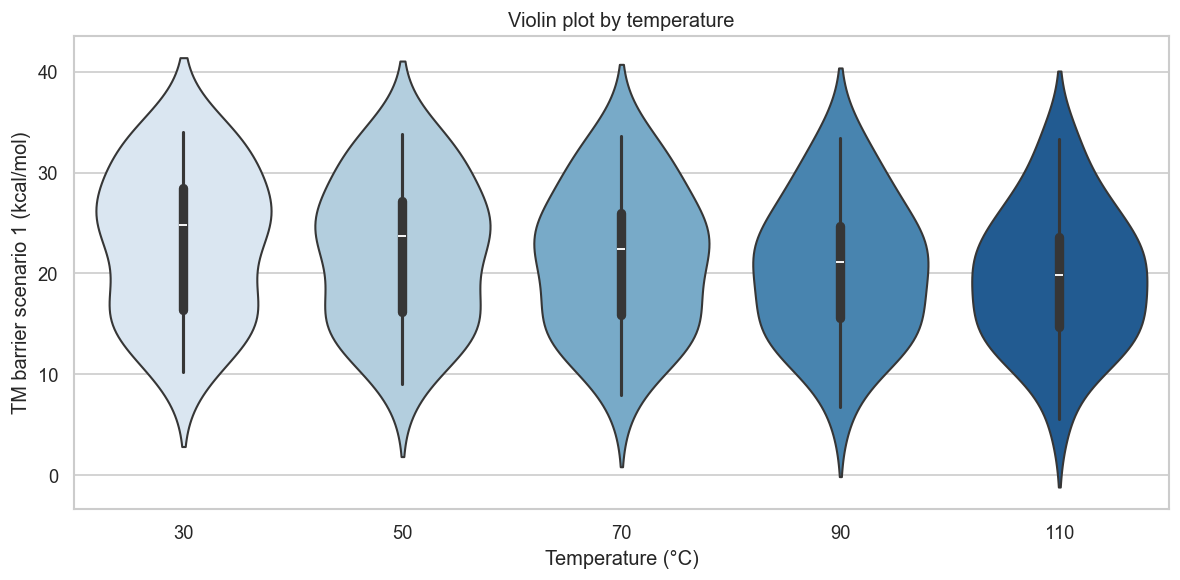

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x='temp_C', y=TARGET, palette='Blues', inner='box', ax=ax)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('TM barrier scenario 1 (kcal/mol)')
ax.set_title('Violin plot by temperature')
plt.tight_layout()
plt.show()

## 4. Analysis by substrate

In [8]:
sub_stats = (
    df.groupby('substrate')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
sub_stats

,mean,median,std,min,max,count
substrate,,,,,,
3_chloropyridine,19.967,19.809,5.234,10.810,32.415,80
3_bromoquinoline,21.407,21.170,7.865,12.795,34.037,30
2_chloropyridine,23.773,26.249,8.651,5.620,33.824,40


C:\Users\livio\AppData\Local\Temp\ipykernel_25836\3114221531.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='substrate', y=TARGET, palette=sub_colors, order=substrates, ax=axes[1])


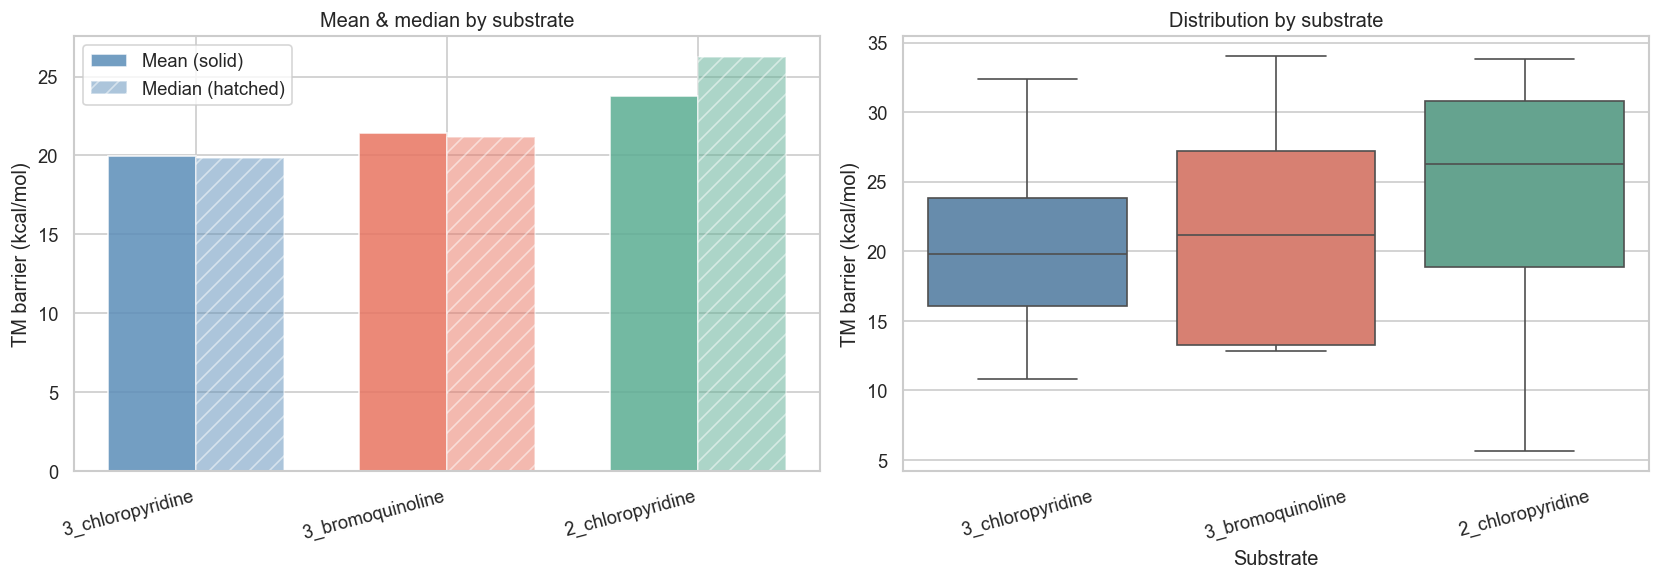

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

substrates = sub_stats.index.tolist()
x = np.arange(len(substrates))
w = 0.35
sub_colors = ['#5B8DB8', '#E87461', '#5BAD92']

axes[0].bar(x - w/2, sub_stats['mean'],   width=w, color=sub_colors, alpha=0.85, label='Mean')
axes[0].bar(x + w/2, sub_stats['median'], width=w, color=sub_colors, alpha=0.5,  hatch='//', label='Median')
axes[0].set_xticks(x)
axes[0].set_xticklabels(substrates, rotation=15, ha='right')
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by substrate')
axes[0].legend(['Mean (solid)', 'Median (hatched)'])

sns.boxplot(data=df, x='substrate', y=TARGET, palette=sub_colors, order=substrates, ax=axes[1])
axes[1].set_xlabel('Substrate')
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by substrate')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

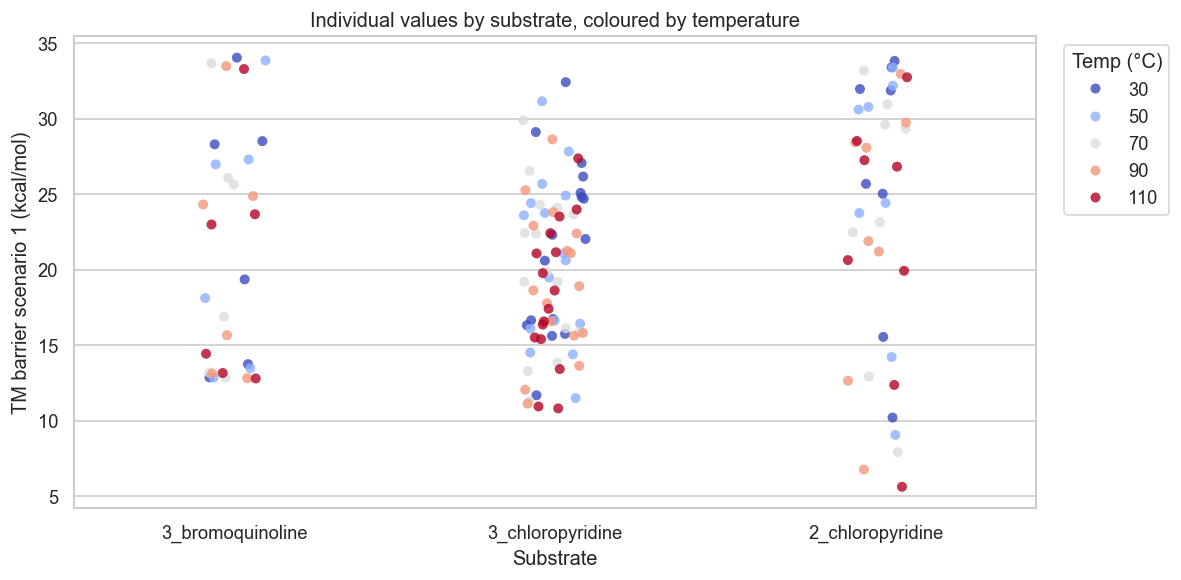

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=df, x='substrate', y=TARGET, hue='temp_C',
              palette='coolwarm', jitter=True, size=6, alpha=0.8, ax=ax)
ax.set_xlabel('Substrate')
ax.set_ylabel('TM barrier scenario 1 (kcal/mol)')
ax.set_title('Individual values by substrate, coloured by temperature')
ax.legend(title='Temp (°C)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Analysis by ligand

In [11]:
lig_stats = (
    df.groupby('ligand')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
lig_stats

,mean,median,std,min,max,count
ligand,,,,,,
tBu3,11.557,12.236,2.574,5.620,15.611,20
Catacxium_A,18.005,16.373,3.342,14.430,25.680,20
SPhos,18.139,16.154,6.897,10.810,31.865,20
AmPhos,18.439,19.193,4.059,12.363,25.082,15
RuPhos,22.883,21.079,5.267,16.362,31.958,15
XPhos,24.174,24.201,1.992,19.922,28.299,20
PPh3,26.810,26.353,3.249,21.151,33.399,20
PCy3,29.847,32.576,4.688,21.072,34.037,20


C:\Users\livio\AppData\Local\Temp\ipykernel_25836\3524323678.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='ligand', x=TARGET, order=ligands,


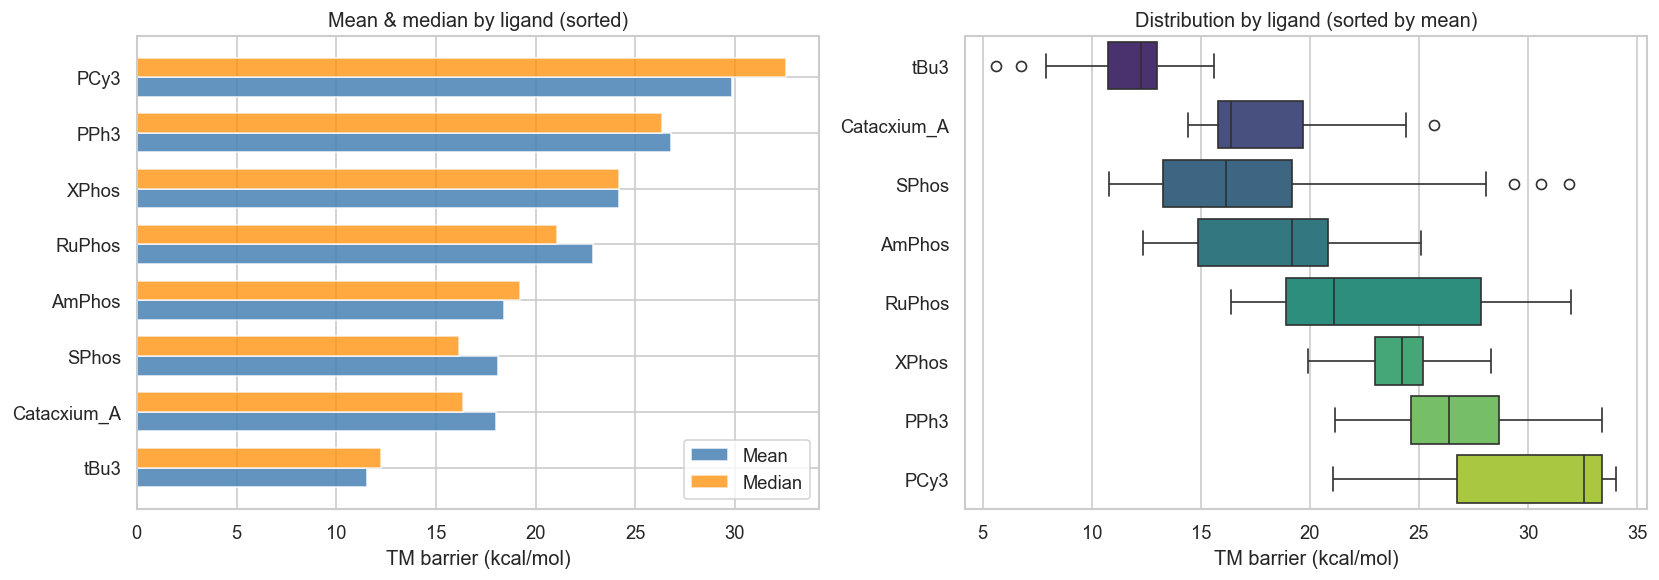

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ligands = lig_stats.index.tolist()
y = np.arange(len(ligands))
w = 0.35

axes[0].barh(y - w/2, lig_stats['mean'],   height=w, label='Mean',   color='steelblue',  alpha=0.85)
axes[0].barh(y + w/2, lig_stats['median'], height=w, label='Median', color='darkorange', alpha=0.75)
axes[0].set_yticks(y)
axes[0].set_yticklabels(ligands)
axes[0].set_xlabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by ligand (sorted)')
axes[0].legend()

sns.boxplot(data=df, y='ligand', x=TARGET, order=ligands,
            palette='viridis', orient='h', ax=axes[1])
axes[1].set_xlabel('TM barrier (kcal/mol)')
axes[1].set_ylabel('')
axes[1].set_title('Distribution by ligand (sorted by mean)')

plt.tight_layout()
plt.show()

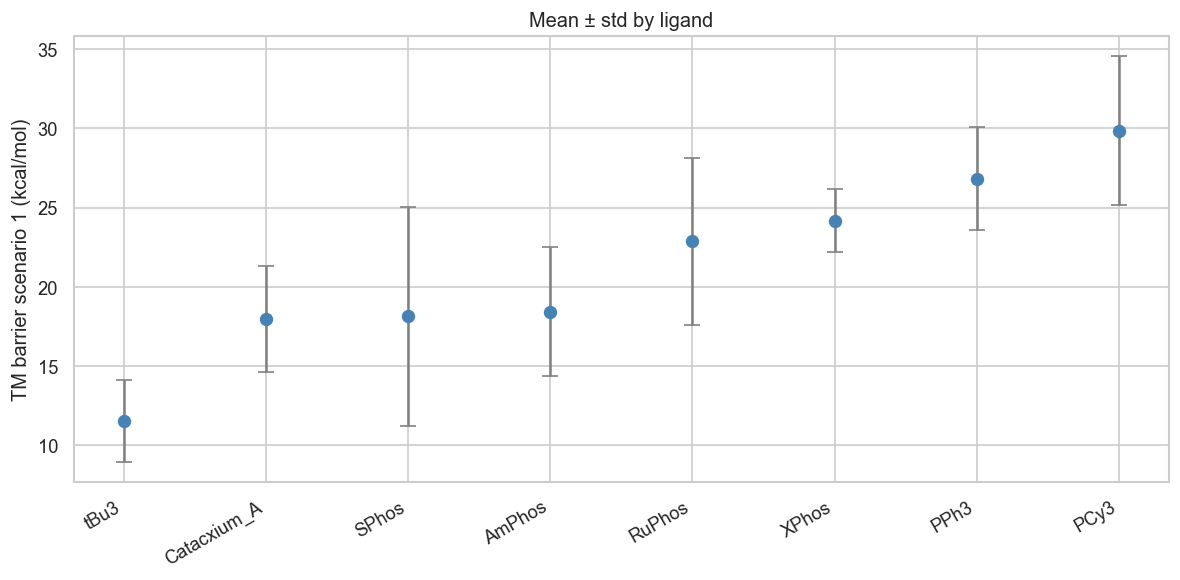

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=range(len(ligands)),
    y=lig_stats['mean'],
    yerr=lig_stats['std'],
    fmt='o', color='steelblue', ecolor='gray',
    elinewidth=1.5, capsize=5, markersize=7
)
ax.set_xticks(range(len(ligands)))
ax.set_xticklabels(ligands, rotation=30, ha='right')
ax.set_ylabel('TM barrier scenario 1 (kcal/mol)')
ax.set_title('Mean ± std by ligand')
plt.tight_layout()
plt.show()

## 6. Analysis by case

In [14]:
case_stats = (
    df.groupby('case')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
case_stats

,mean,median,std,min,max,count
case,,,,,,
case2,19.089,19.194,4.323,10.937,26.164,40
case3,20.845,21.084,5.935,10.810,32.415,40
case1,21.407,21.170,7.865,12.795,34.037,30
case4,23.773,26.249,8.651,5.620,33.824,40


C:\Users\livio\AppData\Local\Temp\ipykernel_25836\219987495.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='case', y=TARGET, palette=case_colors, order=cases, ax=axes[1])


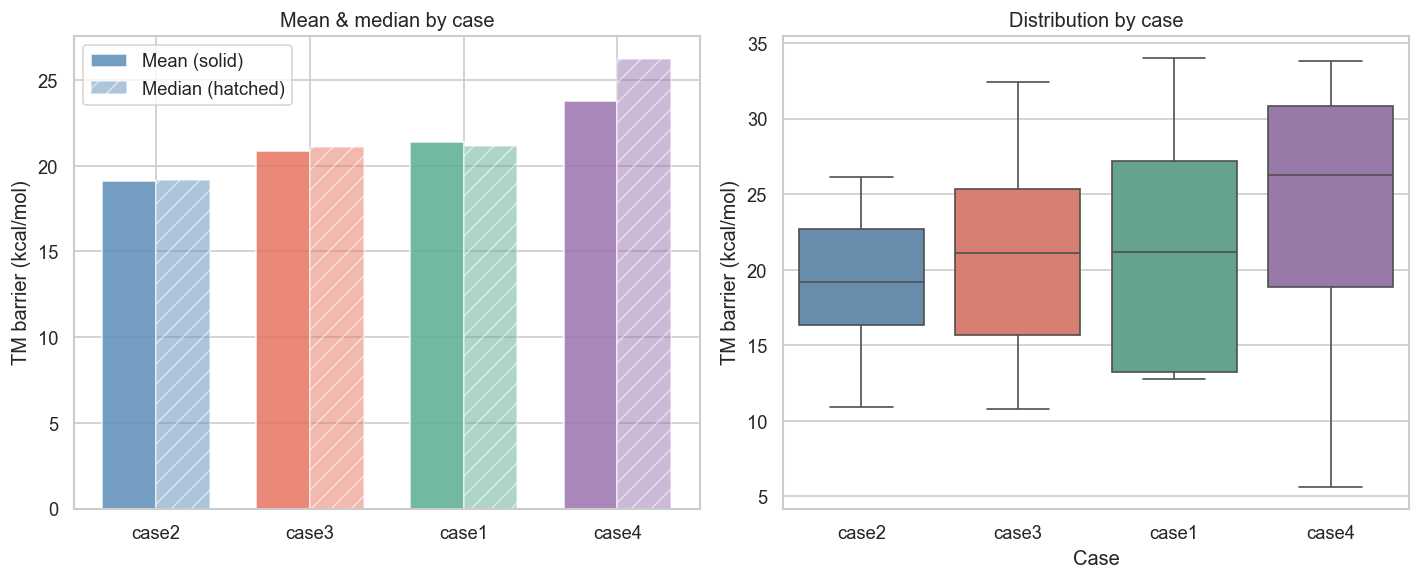

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cases = case_stats.index.tolist()
case_colors = ['#5B8DB8', '#E87461', '#5BAD92', '#9B72B0']

x = np.arange(len(cases))
w = 0.35
axes[0].bar(x - w/2, case_stats['mean'],   width=w, color=case_colors, alpha=0.85, label='Mean')
axes[0].bar(x + w/2, case_stats['median'], width=w, color=case_colors, alpha=0.5,  hatch='//', label='Median')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cases)
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by case')
axes[0].legend(['Mean (solid)', 'Median (hatched)'])

sns.boxplot(data=df, x='case', y=TARGET, palette=case_colors, order=cases, ax=axes[1])
axes[1].set_xlabel('Case')
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by case')

plt.tight_layout()
plt.show()

## 7. Analysis by boron species

In [16]:
boh2_stats = (
    df.groupby('BOH2_short')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
print('BOH2 species:')
display(boh2_stats)

bpin_stats = (
    df.groupby('BPin_short')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
print('BPin species:')
display(bpin_stats)

BOH2 species:


,mean,median,std,min,max,count
BOH2_short,,,,,,
BOH2-cpd2,20.082,19.273,6.156,10.937,34.037,70
BOH2-cpd6,20.845,21.084,5.935,10.810,32.415,40
BOH2-cpd9,23.773,26.249,8.651,5.620,33.824,40


BPin species:


,mean,median,std,min,max,count
BPin_short,,,,,,
BPin-cpd2,20.082,19.273,6.156,10.937,34.037,70
BPin-cpd6,20.845,21.084,5.935,10.810,32.415,40
BPin-cpd9,23.773,26.249,8.651,5.620,33.824,40


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
boron_colors = ['#5B8DB8', '#E87461', '#5BAD92']

sns.boxplot(data=df, x='BOH2_short', y=TARGET, palette=boron_colors,
            order=boh2_stats.index.tolist(), ax=axes[0])
axes[0].set_xlabel('BOH2 species')
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Distribution by BOH2 species')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='BPin_short', y=TARGET, palette=boron_colors,
            order=bpin_stats.index.tolist(), ax=axes[1])
axes[1].set_xlabel('BPin species')
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by BPin species')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Heatmap: ligand × substrate (mean TM barrier)

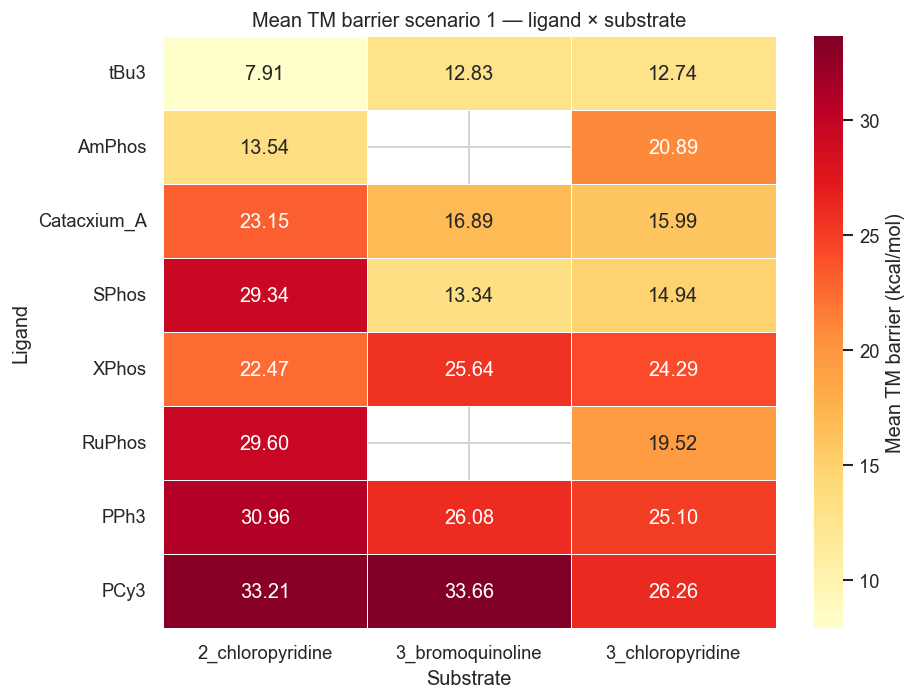

In [79]:
pivot_sub = df.pivot_table(values=TARGET, index='ligand', columns='substrate', aggfunc='mean')

# Rank ligands by their overall mean (lowest to highest)
pivot_sub = pivot_sub.loc[pivot_sub.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × substrate')
ax.set_xlabel('Substrate')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

### 30°C specifically

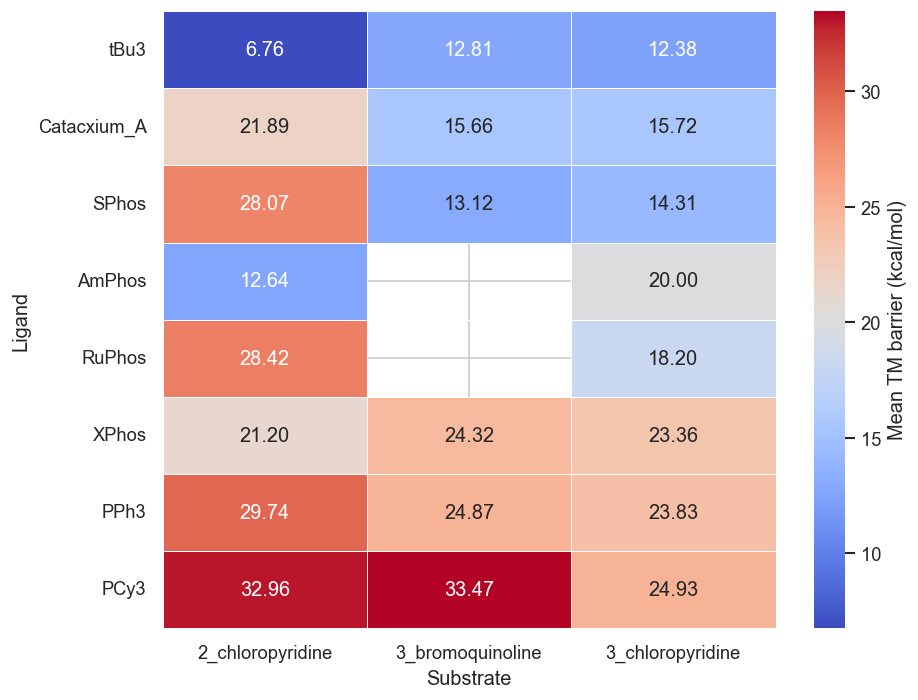

In [17]:
df_30 = df[df['temp_C'] == 90]
pivot_sub = df_30.pivot_table(values=TARGET, index='ligand', columns='substrate', aggfunc='mean')
pivot_sub = pivot_sub.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 - 30°C — ligand × substrate')
ax.set_xlabel('Substrate')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 9. Heatmap: ligand × temperature (mean TM barrier)

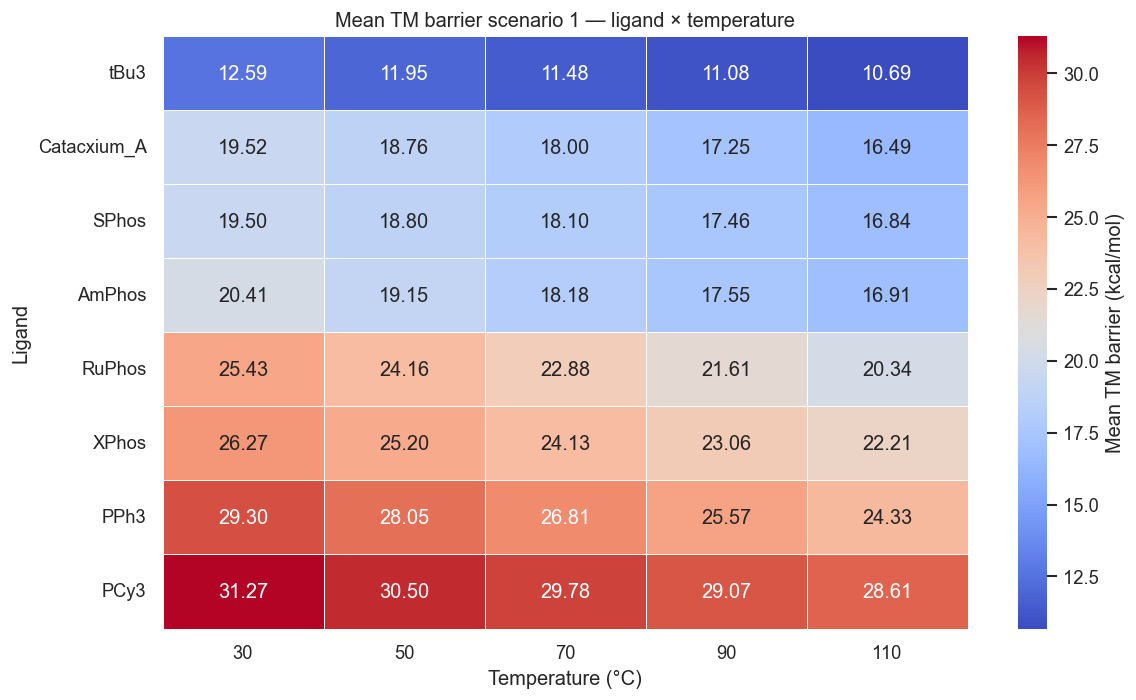

In [18]:
# For all cases combined
pivot_temp = df.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')
pivot_temp = pivot_temp.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × temperature')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

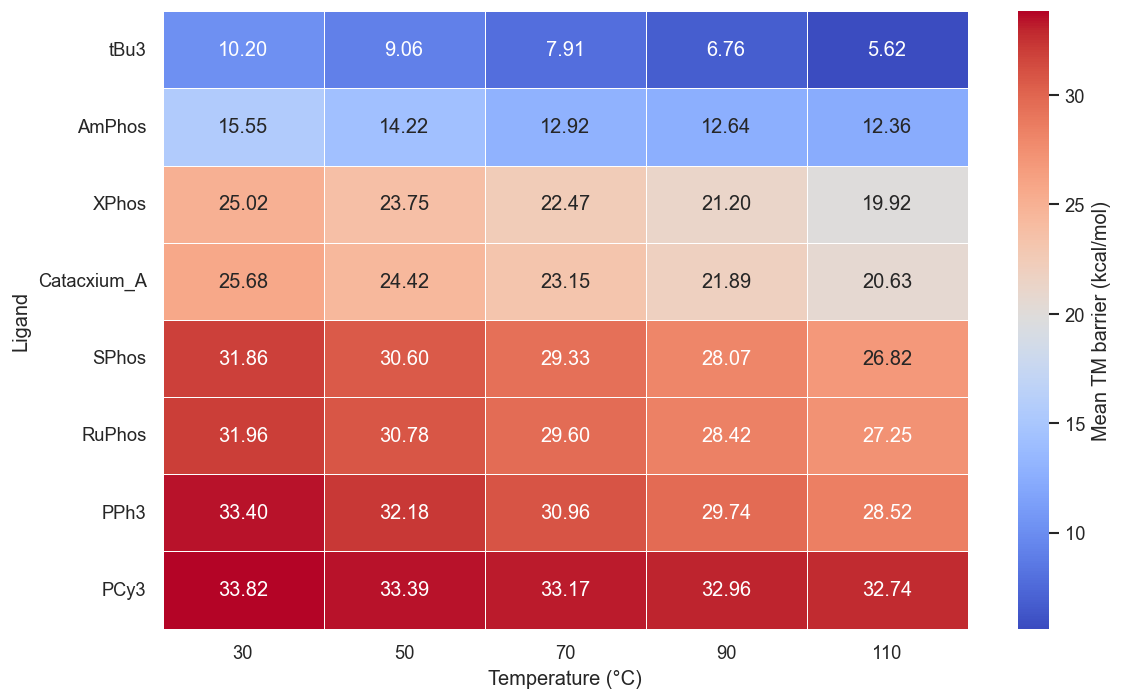

In [19]:
# For case 4 specifically
df_case4 = df[df['case'] == 'case4']

pivot_temp = df_case4.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')

# Rank ligands by their overall mean (lowest to highest)
pivot_temp = pivot_temp.loc[pivot_temp.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 — ligand × temperature (case4 only)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

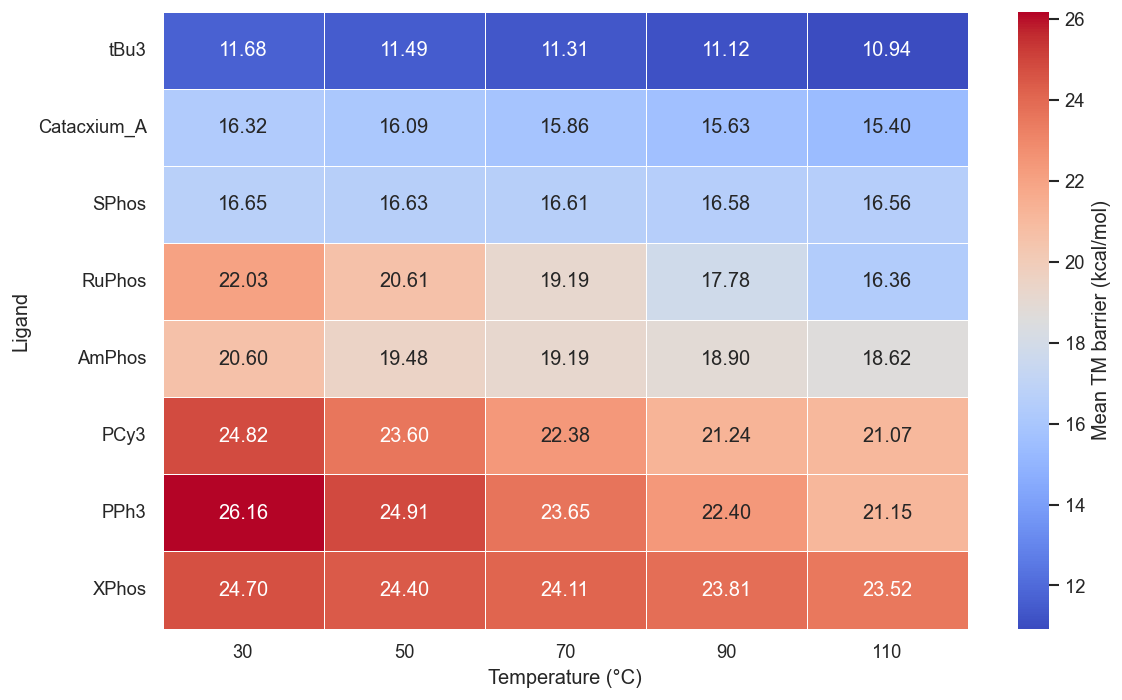

In [20]:
# For case 1 specifically
df_case4 = df[df['case'] == 'case2']

pivot_temp = df_case4.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')

# Rank ligands by their overall mean (lowest to highest)
pivot_temp = pivot_temp.loc[pivot_temp.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 — ligand × temperature (case4 only)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

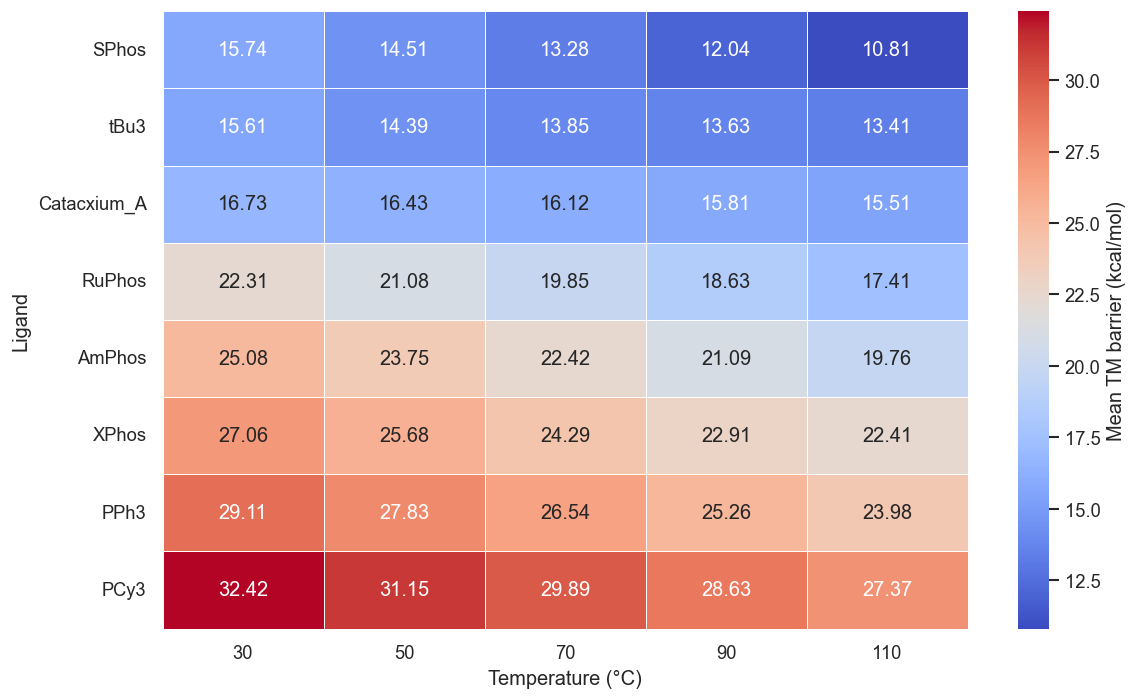

In [21]:
# For case 1 specifically
df_case4 = df[df['case'] == 'case3']

pivot_temp = df_case4.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')

# Rank ligands by their overall mean (lowest to highest)
pivot_temp = pivot_temp.loc[pivot_temp.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 — ligand × temperature (case4 only)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

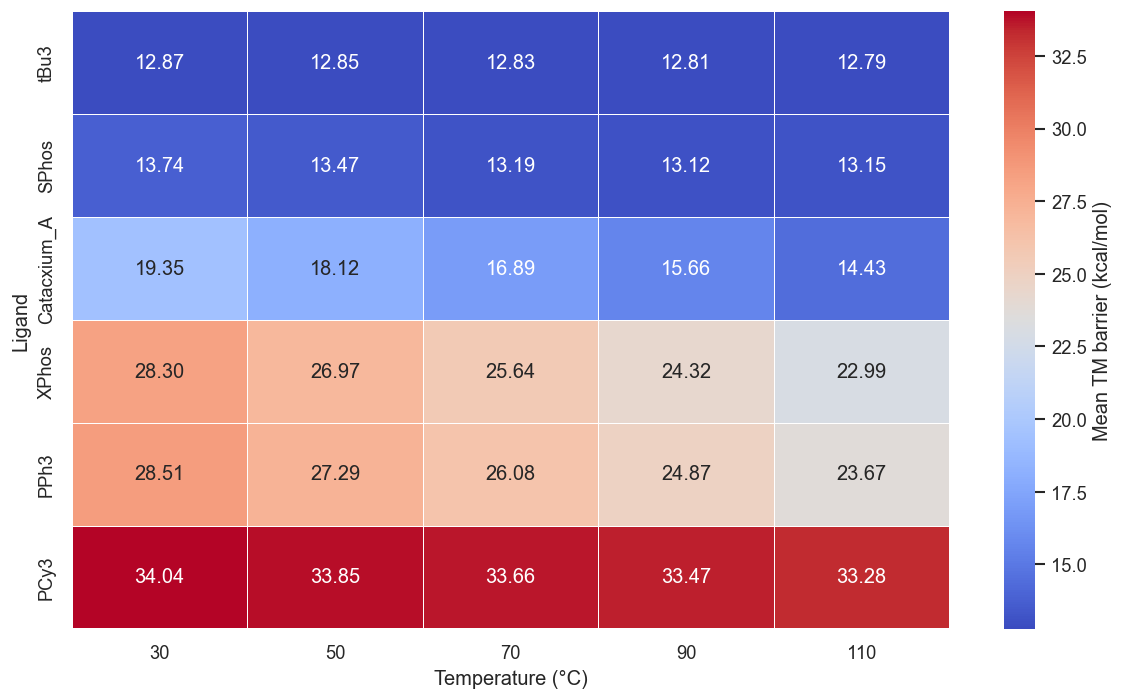

In [22]:
# For case 4 specifically
df_case4 = df[df['case'] == 'case1']

pivot_temp = df_case4.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')

# Rank ligands by their overall mean (lowest to highest)
pivot_temp = pivot_temp.loc[pivot_temp.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 — ligand × temperature (case4 only)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 10. Heatmap: ligand × case (mean TM barrier)

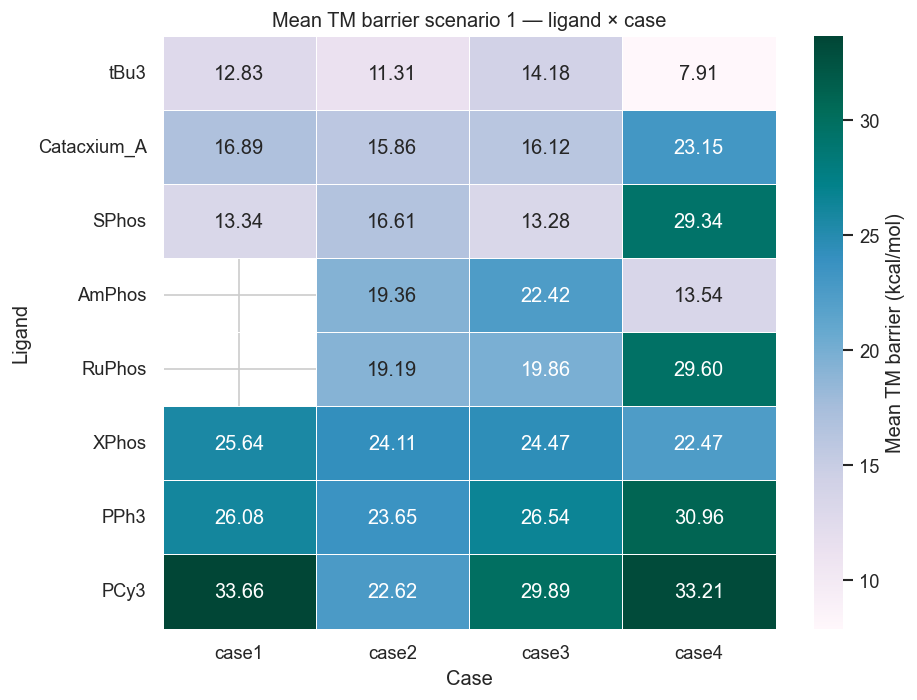

In [70]:
pivot_case = df.pivot_table(values=TARGET, index='ligand', columns='case', aggfunc='mean')
pivot_case = pivot_case.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_case, annot=True, fmt='.2f', cmap='PuBuGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × case')
ax.set_xlabel('Case')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

#### 90°C specifically

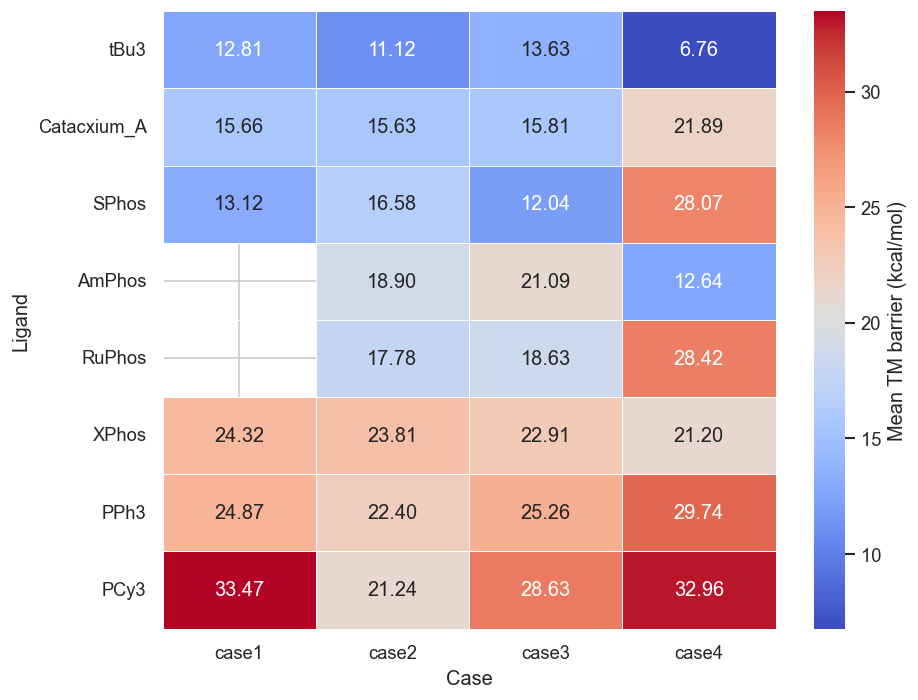

In [81]:
df_30_TM = df[df['temp_C'] == 90]
pivot_sub = df_30_TM.pivot_table(values=TARGET, index='ligand', columns='case', aggfunc='mean')

# Rank ligands by their overall mean (lowest to highest)
pivot_sub = pivot_sub.loc[pivot_sub.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 - 90°C — ligand × substrate')
ax.set_xlabel('Case')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 11. Interaction: barrier vs temperature, per ligand

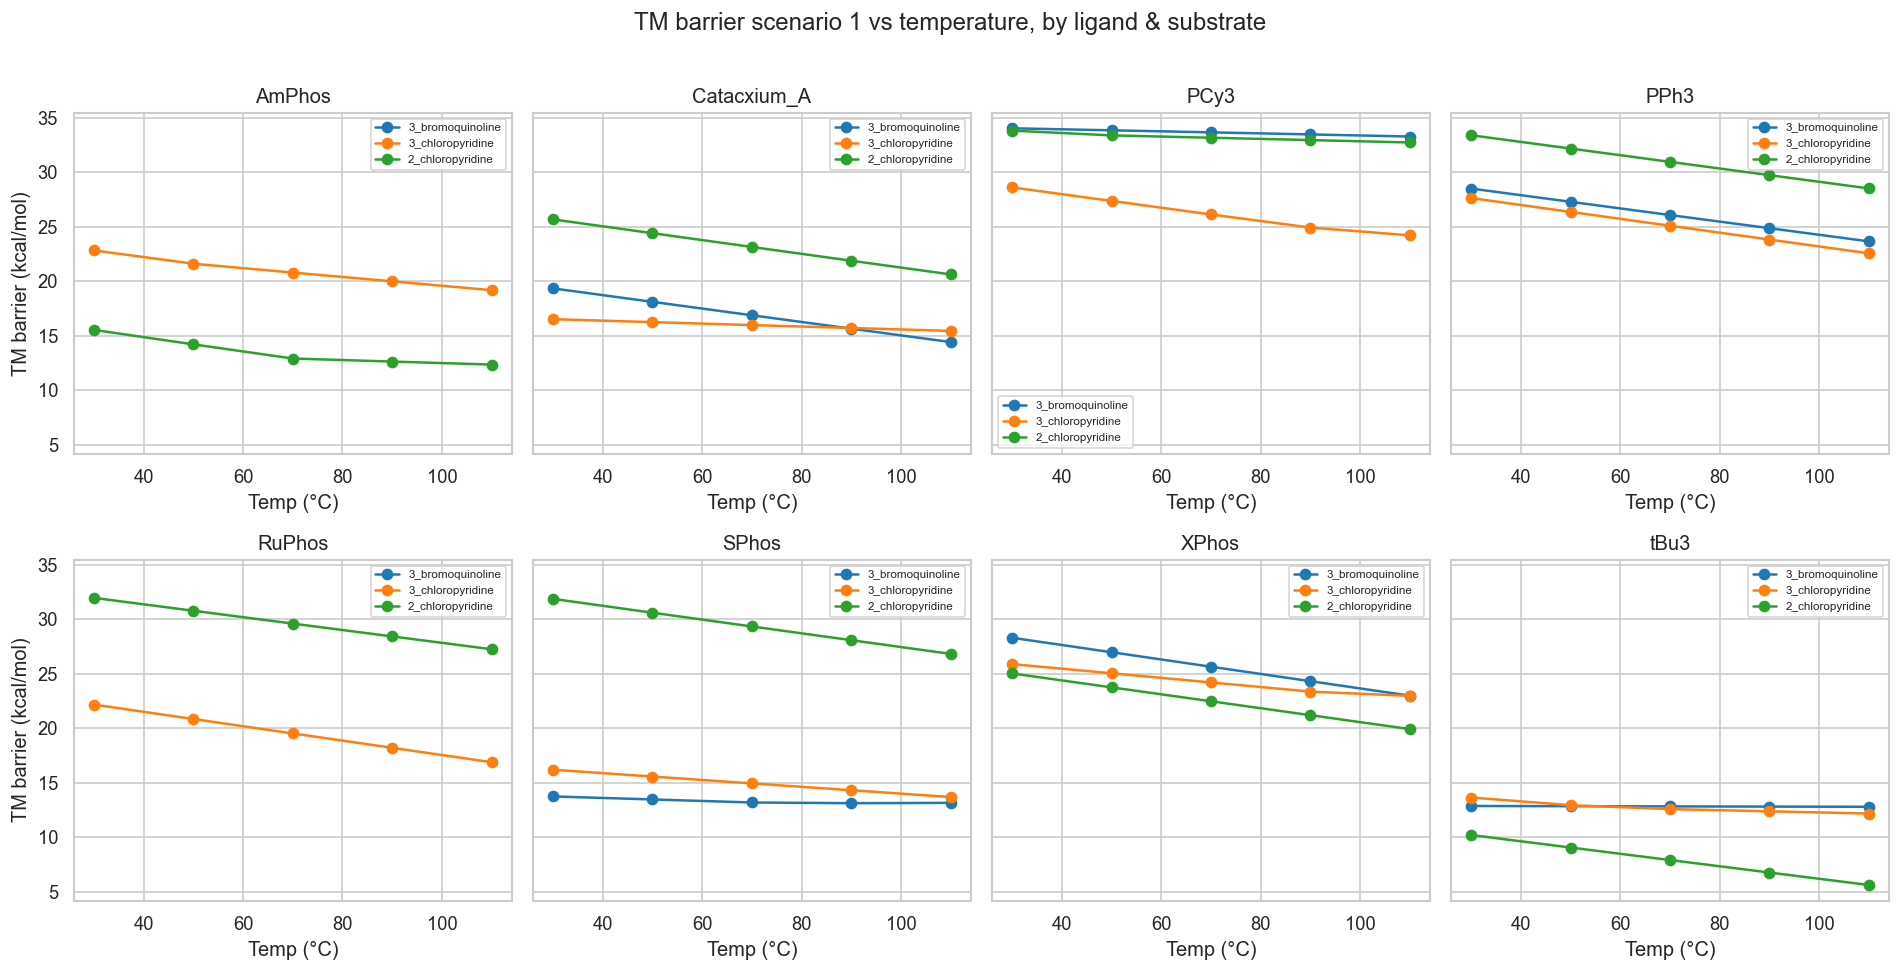

In [72]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', len(df['substrate'].unique()))

for i, lig in enumerate(sorted(df['ligand'].unique())):
    sub_df = df[df['ligand'] == lig]
    for j, sub in enumerate(df['substrate'].unique()):
        s = sub_df[sub_df['substrate'] == sub].groupby('temp_C')[TARGET].mean().reset_index()
        axes[i].plot(s['temp_C'], s[TARGET], marker='o', label=sub, color=palette[j])
    axes[i].set_title(lig)
    axes[i].set_xlabel('Temp (°C)')
    if i % 4 == 0:
        axes[i].set_ylabel('TM barrier (kcal/mol)')
    axes[i].legend(fontsize=7)

plt.suptitle('TM barrier scenario 1 vs temperature, by ligand & substrate', y=1.01)
plt.tight_layout()
plt.show()

## 12. Summary statistics table

In [ ]:
summary = (
    df.groupby(['ligand', 'substrate', 'temp_C', 'case'])[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
    .reset_index()
)
summary.head(20)